# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [37]:
data = pd.read_csv('Iris.csv')
# Drop kolom ID dan encode Species sebelum EDA
data.drop('Id', axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder
le_species = LabelEncoder()
data['Species'] = le_species.fit_transform(data['Species'])
print("Mapping Species:", dict(zip(le_species.classes_, le_species.transform(le_species.classes_))))
data.head()

Mapping Species: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Exploratory Data Analysis

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
d = data.describe()
d

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_9060\1775346773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=data, palette='Set2')


Text(0.5, 1.0, 'Distribusi Jenis Bunga Iris')

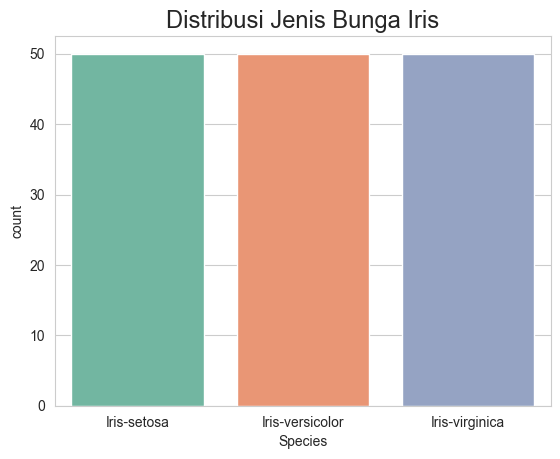

In [9]:
# Cek distribusi dari jenis bunga iris
sns.set_style('whitegrid')
sns.countplot(x='Species', data=data, palette='Set2')
plt.title('Distribusi Jenis Bunga Iris', fontsize=17)

<Axes: xlabel='Survived', ylabel='count'>

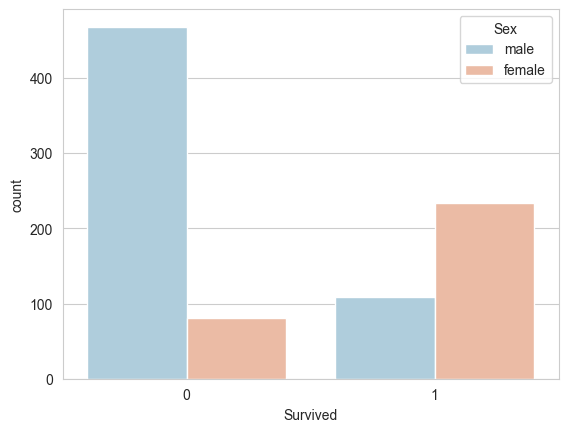

In [5]:
# Sepal Length vs Species
sns.set_style('whitegrid')
sns.boxplot(x='Species', y='SepalLengthCm', data=data, palette='Set2')
plt.title('Distribusi Sepal Length per Jenis Bunga', fontsize=17)

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_9060\3504449260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='PetalLengthCm', data=data, palette='Set2')


Text(0.5, 1.0, 'Distribusi Petal Length per Jenis Bunga')

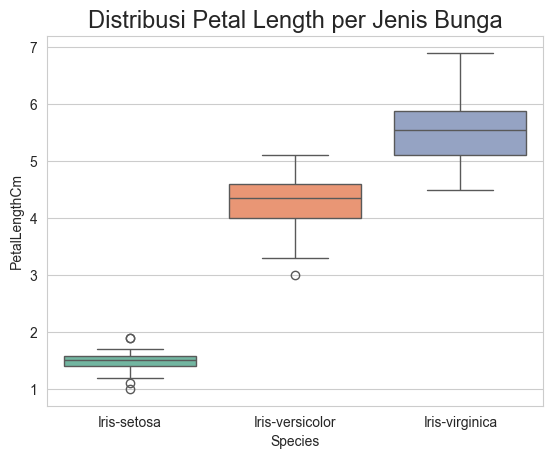

In [10]:
# Petal Length vs Species
sns.set_style('whitegrid')
sns.boxplot(x='Species', y='PetalLengthCm', data=data, palette='Set2')
plt.title('Distribusi Petal Length per Jenis Bunga', fontsize=17)

Text(0.5, 1.0, 'Korelasi antar Fitur Iris')

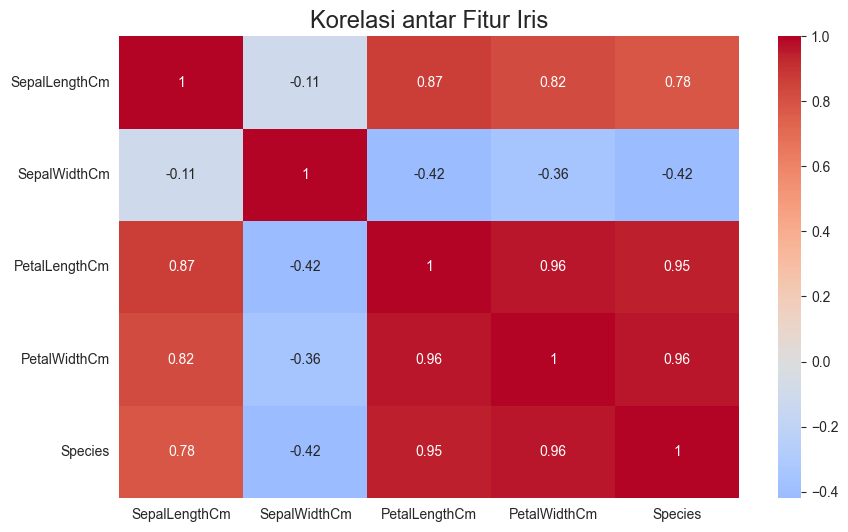

In [27]:
plt.figure(figsize=(10, 6))
# Heatmap korelasi antar fitur (hanya kolom numerik)
correlation = data.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Korelasi antar Fitur Iris', fontsize=17)

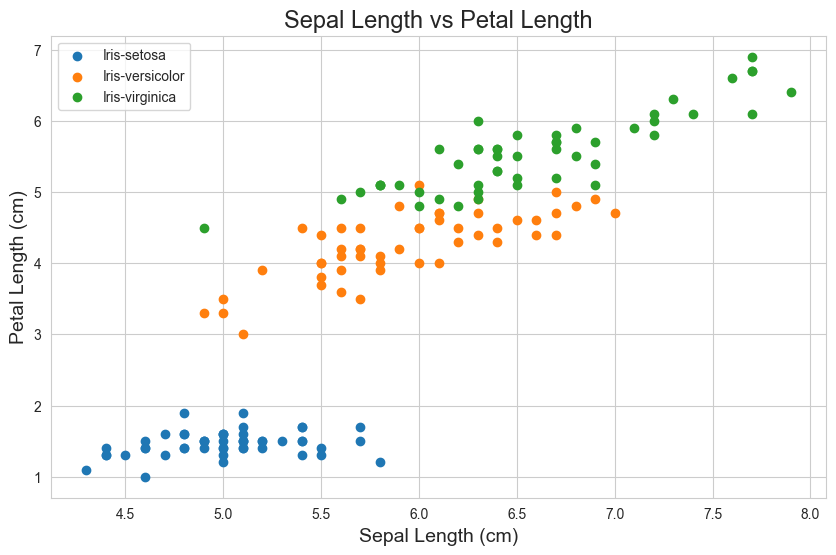

In [28]:
# Scatter plot Sepal Length vs Petal Length
plt.figure(figsize=(10, 6))
species_names = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
for species_code in sorted(data['Species'].unique()):
    subset = data[data['Species'] == species_code]
    plt.scatter(subset['SepalLengthCm'], subset['PetalLengthCm'], label=species_names[species_code])
plt.xlabel('Sepal Length (cm)', fontsize=14)
plt.ylabel('Petal Length (cm)', fontsize=14)
plt.title('Sepal Length vs Petal Length', fontsize=17)
plt.legend()

In [13]:
# Statistik deskriptif
data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [14]:
# Info data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


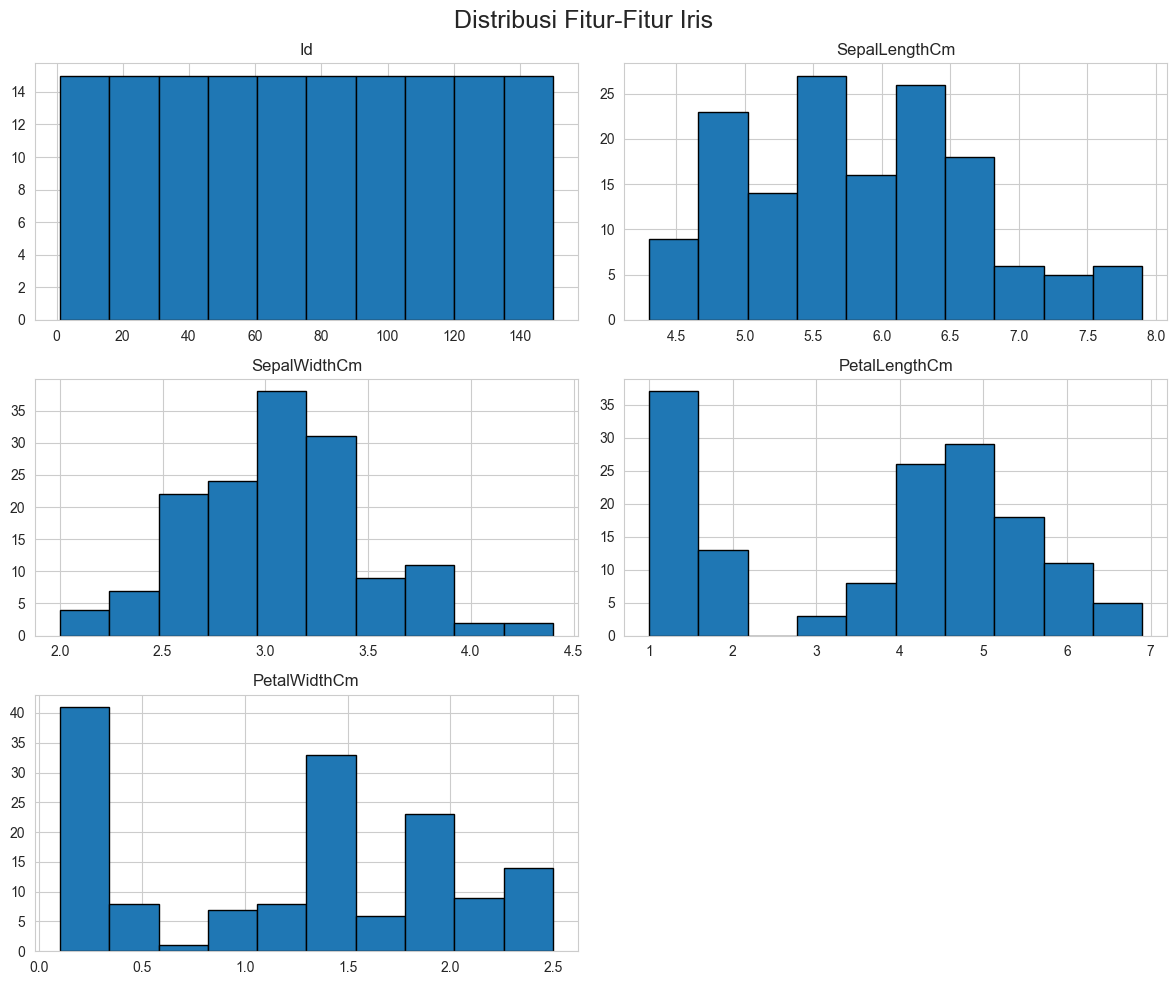

In [15]:
# Distribusi histogram semua fitur
data.hist(figsize=(12, 10), edgecolor='black')
plt.suptitle('Distribusi Fitur-Fitur Iris', fontsize=18)
plt.tight_layout()

### Fitur Engineering

In [16]:
# Rename variable to match new dataset name
train = data.copy()

### Training

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.drop('Species', axis=1),
                                                    data['Species'], test_size=0.30,
                                                    random_state=42)

In [39]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print(f'Kolom X_train: {X_train.columns.tolist()}')

Train shape: (105, 4)
Test shape: (45, 4)
Kolom X_train: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


# **KNN**

In [20]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
y_pred = clf1.predict(X_test)

### Evaluation

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [23]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall': make_scorer(recall_score, average='macro', zero_division=0),
    'f1': make_scorer(f1_score, average='macro', zero_division=0)
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=0, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))


=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
0   {'metric': 'euclidea

In [52]:
# Simpan hasil evaluasi (Excel atau CSV)
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
try:
    cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)
    print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")
except:
    cv_metrics_sorted.to_csv("hasil_gridsearch_knn.csv", index=False)
    print("Hasil telah disimpan ke 'hasil_gridsearch_knn.csv' (Excel tidak tersedia)")

Hasil telah disimpan ke 'hasil_gridsearch_knn.csv' (Excel tidak tersedia)


In [46]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [47]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [48]:
import numpy as np
import pandas as pd

# Data bunga iris baru (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm)
# Buat DataFrame dengan nama kolom yang sama seperti saat training
new_data = pd.DataFrame([[6.0, 3.0, 4.5, 1.5]], 
                        columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

# Prediksi jenis bunga iris
prediction = best_model.predict(new_data)

# Decode hasil prediksi
iris_species = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
print(f"Prediksi jenis bunga: {iris_species[prediction[0]]}")
print(f"Kode: {prediction[0]}")

Prediksi jenis bunga: Iris-versicolor
Kode: 1


In [54]:

# ============================================
# KNN dengan K=5 dan Data Baru: x1=6, x2=5
# ============================================

# Buat model KNN dengan K=5 spesifik
knn_k5 = KNeighborsClassifier(n_neighbors=5)
knn_k5.fit(X_train, y_train)

# Data baru: x1=6 (SepalLengthCm), x2=5 (SepalWidthCm)
# Tambahkan nilai default untuk fitur yang lain
new_point = pd.DataFrame([[6.0, 5.0, 3.5, 1.0]], 
                         columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

# Prediksi
pred_k5 = knn_k5.predict(new_point)[0]

# Hitung jarak dan temukan 5 tetangga terdekat
distances, indices = knn_k5.kneighbors(new_point, n_neighbors=5)

print("\n" + "="*60)
print("PREDIKSI KNN DENGAN K=5")
print("="*60)
print(f"\nData Baru:")
print(f"  SepalLengthCm: 6.0")
print(f"  SepalWidthCm:  5.0")
print(f"  PetalLengthCm: 3.5")
print(f"  PetalWidthCm:  1.0")

print(f"\n>>> PREDIKSI: {iris_species[pred_k5]} (Kode: {pred_k5})")

print(f"\n5 Tetangga Terdekat:")
print("-" * 60)
for i, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
    neighbor_species = iris_species[y_train.iloc[idx]]
    print(f"{i}. Jarak: {dist:.4f} | Spesies: {neighbor_species}")

# Hitung voting untuk prediksi
neighbor_classes = y_train.iloc[indices[0]]
from collections import Counter
vote_count = Counter(neighbor_classes)
print(f"\nHasil Voting:")
for species_code, count in vote_count.most_common():
    print(f"  {iris_species[species_code]}: {count} vote(s)")



PREDIKSI KNN DENGAN K=5

Data Baru:
  SepalLengthCm: 6.0
  SepalWidthCm:  5.0
  PetalLengthCm: 3.5
  PetalWidthCm:  1.0

>>> PREDIKSI: Iris-versicolor (Kode: 1)

5 Tetangga Terdekat:
------------------------------------------------------------
1. Jarak: 2.1471 | Spesies: Iris-versicolor
2. Jarak: 2.1494 | Spesies: Iris-versicolor
3. Jarak: 2.1794 | Spesies: Iris-versicolor
4. Jarak: 2.2539 | Spesies: Iris-versicolor
5. Jarak: 2.2738 | Spesies: Iris-setosa

Hasil Voting:
  Iris-versicolor: 4 vote(s)
  Iris-setosa: 1 vote(s)


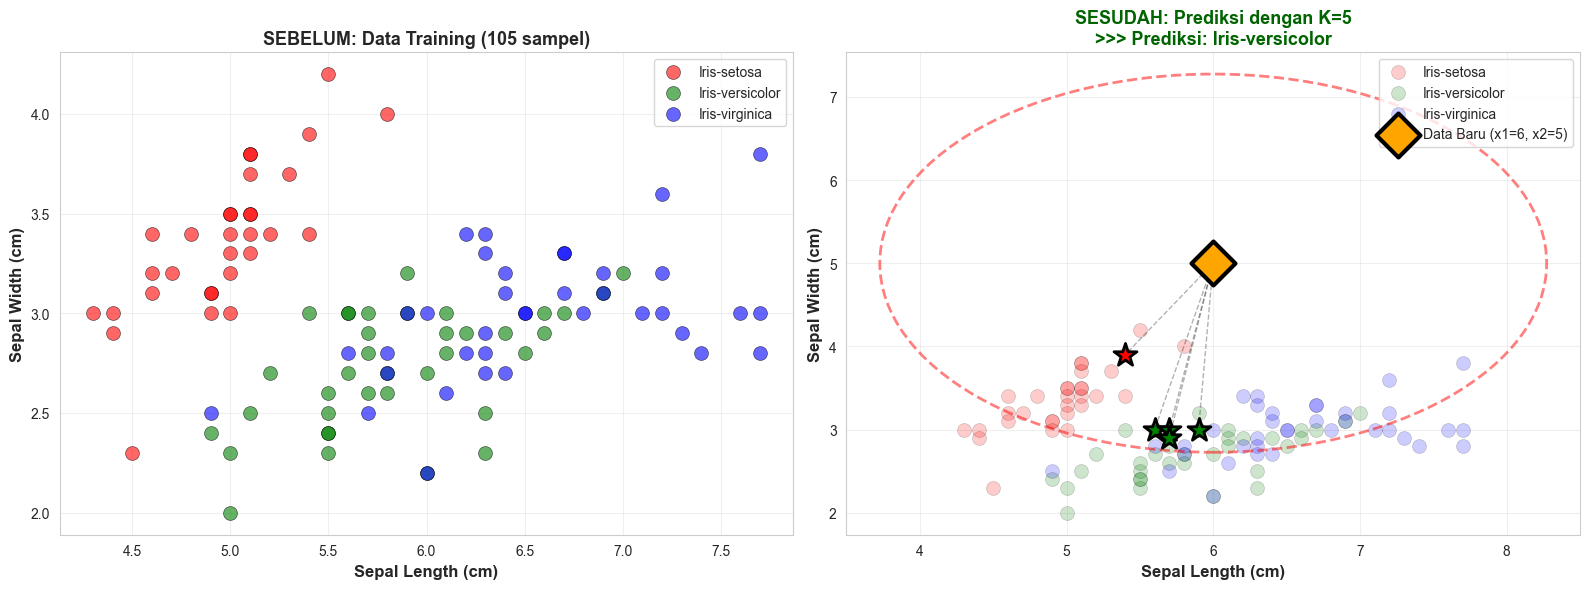


VISUALISASI PENJELASAN:
• Plot Kiri  : Semua data training (105 sampel) untuk training model
• Plot Kanan : Data baru (berlian oranye) dengan 5 tetangga terdekatnya
              (ditampilkan dengan bintang besar)
• Garis putus: Jarak dari data baru ke setiap tetangga terdekat
• Lingkaran  : Radius pencarian K=5 tetangga terdekat (max distance)


In [56]:

# ============================================
# VISUALISASI: SEBELUM DAN SESUDAH PREDIKSI
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color mapping untuk species
species_colors = {0: 'red', 1: 'green', 2: 'blue'}
species_names = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}

# ===== PLOT 1: SEBELUM (Data Training) =====
ax1 = axes[0]
for species_code in [0, 1, 2]:
    mask = y_train.values == species_code
    ax1.scatter(X_train.values[mask, 0], X_train.values[mask, 1], 
               c=species_colors[species_code], label=species_names[species_code], 
               s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Sepal Length (cm)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sepal Width (cm)', fontsize=12, fontweight='bold')
ax1.set_title('SEBELUM: Data Training (105 sampel)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# ===== PLOT 2: SESUDAH (Data Baru + 5 Tetangga Terdekat) =====
ax2 = axes[1]

# Plot semua data training dengan alpha rendah
for species_code in [0, 1, 2]:
    mask = y_train.values == species_code
    ax2.scatter(X_train.values[mask, 0], X_train.values[mask, 1], 
               c=species_colors[species_code], label=species_names[species_code], 
               s=100, alpha=0.2, edgecolors='black', linewidth=0.5)

# Highlight 5 tetangga terdekat
neighbor_indices = indices[0]
for i, idx in enumerate(neighbor_indices):
    neighbor_data = X_train.iloc[idx]
    neighbor_class = y_train.iloc[idx]
    
    # Plot tetangga dengan marker bintang
    ax2.scatter(neighbor_data['SepalLengthCm'], neighbor_data['SepalWidthCm'], 
               c=species_colors[neighbor_class], s=300, marker='*', 
               edgecolors='black', linewidth=2, zorder=4)
    
    # Draw line dari data baru ke tetangga
    ax2.plot([new_point['SepalLengthCm'].values[0], neighbor_data['SepalLengthCm']], 
            [new_point['SepalWidthCm'].values[0], neighbor_data['SepalWidthCm']], 
            'k--', alpha=0.3, linewidth=1, zorder=2)

# Plot data baru dengan marker khusus
ax2.scatter(new_point['SepalLengthCm'], new_point['SepalWidthCm'], 
           c='orange', s=500, marker='D', edgecolors='black', linewidth=3, 
           label=f'Data Baru (x1=6, x2=5)', zorder=5)

# Circle untuk menunjukkan radius
from matplotlib.patches import Circle
max_distance = distances[0][-1]
circle = Circle((new_point['SepalLengthCm'].values[0], new_point['SepalWidthCm'].values[0]), 
               max_distance, color='red', fill=False, linestyle='--', linewidth=2, alpha=0.5, zorder=3)
ax2.add_patch(circle)

ax2.set_xlabel('Sepal Length (cm)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sepal Width (cm)', fontsize=12, fontweight='bold')
ax2.set_title(f'SESUDAH: Prediksi dengan K=5\n>>> Prediksi: {iris_species[pred_k5]}', 
             fontsize=13, fontweight='bold', color='darkgreen')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VISUALISASI PENJELASAN:")
print("="*70)
print("• Plot Kiri  : Semua data training (105 sampel) untuk training model")
print("• Plot Kanan : Data baru (berlian oranye) dengan 5 tetangga terdekatnya")
print("              (ditampilkan dengan bintang besar)")
print("• Garis putus: Jarak dari data baru ke setiap tetangga terdekat")
print("• Lingkaran  : Radius pencarian K=5 tetangga terdekat (max distance)")
print("="*70)
